# Global Pipeline

## 1. Imports and Setup

In [1]:
import sys
from pathlib import Path

In [2]:
REPO_ROOT = Path.cwd().parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [3]:
from bppm_dem_sm.config import PROCESSED_DIR, MODELS_DIR
from bppm_dem_sm import PipelineConfig
from bppm_dem_sm import prediction, run_metrics, run_visualization, training

In [4]:
print("Repo root:", REPO_ROOT)
print("Processed data dir:", PROCESSED_DIR)
print("Models dir:", MODELS_DIR)

Repo root: c:\Users\Fernando\OneDrive - electro controles del noroeste\MCD\repo_tt\bi-poly-particle-mix-dem-sgt-model
Processed data dir: C:\Users\Fernando\OneDrive - electro controles del noroeste\MCD\repo_tt\bi-poly-particle-mix-dem-sgt-model\data\processed
Models dir: C:\Users\Fernando\OneDrive - electro controles del noroeste\MCD\repo_tt\bi-poly-particle-mix-dem-sgt-model\models


In [5]:
%matplotlib inline

## 2. Configurations

In [ ]:
# INTEGRAR ARGS para introducir argumentos al pipeline (dar opcion de usar un JSON/YAML talvez ?)

config = PipelineConfig(
    data_dir=PROCESSED_DIR / "sic_dataset_20s_dt0p0001_parquet",
    train_data_dir=PROCESSED_DIR / "sic_training_dataset_3s_4s_parquet",
    model_path=MODELS_DIR / "rnn_gru_sic_model",
    do_train=False,        # set True to retrain and overwrite the saved model
    do_predict=True,
    do_metrics=True,
    do_visualization=True,
    start_frame=66,
    frames_in=15,
    autoregressive=False,
    show_plots=True,
    save_figures=False,
)

In [10]:
config

PipelineConfig(data_dir=WindowsPath('C:/Users/Fernando/OneDrive - electro controles del noroeste/MCD/repo_tt/bi-poly-particle-mix-dem-sgt-model/data/processed/sic_dataset_20s_dt0p0001_parquet'), train_data_dir=WindowsPath('C:/Users/Fernando/OneDrive - electro controles del noroeste/MCD/repo_tt/bi-poly-particle-mix-dem-sgt-model/data/processed/sic_training_dataset_3s_4s_parquet'), frame_glob='frame_*.parquet', feature_cols=['x', 'y', 'z', 'r'], model_path=WindowsPath('C:/Users/Fernando/OneDrive - electro controles del noroeste/MCD/repo_tt/bi-poly-particle-mix-dem-sgt-model/models/rnn_gru_sic_model'), frames_in=15, do_train=False, epochs=20, batch_size=500, learning_rate=0.01, val_fraction=0.1, seed=0, gru_units=20, dense_units=15, do_predict=True, start_frame=66, autoregressive=False, predict_until_end=True, max_steps=200, predict_batch_size=2048, dt0=4.05, dt_step=0.05, pred_out_dir=WindowsPath('C:/Users/Fernando/OneDrive - electro controles del noroeste/MCD/repo_tt/bi-poly-particle-mi

## 3. Simulacion (YADE DEM)

## 4. Model

### 4.1 Building

### 4.2 Training

In [ ]:
model, history = training.train_and_save(config)

### 4.3 Prediction

In [7]:
preds = prediction.predict_frames(config)

Model input_shape: (None, 15, 4) output_shape: (None, 3)
Predicted & saved 10/319 frames...
Predicted & saved 20/319 frames...
Predicted & saved 30/319 frames...
Predicted & saved 40/319 frames...
Predicted & saved 50/319 frames...
Predicted & saved 60/319 frames...
Predicted & saved 70/319 frames...
Predicted & saved 80/319 frames...
Predicted & saved 90/319 frames...
Predicted & saved 100/319 frames...
Predicted & saved 110/319 frames...
Predicted & saved 120/319 frames...
Predicted & saved 130/319 frames...
Predicted & saved 140/319 frames...
Predicted & saved 150/319 frames...
Predicted & saved 160/319 frames...
Predicted & saved 170/319 frames...
Predicted & saved 180/319 frames...
Predicted & saved 190/319 frames...
Predicted & saved 200/319 frames...
Predicted & saved 210/319 frames...
Predicted & saved 220/319 frames...
Predicted & saved 230/319 frames...
Predicted & saved 240/319 frames...
Predicted & saved 250/319 frames...
Predicted & saved 260/319 frames...
Predicted & save

## 5. Metrics

In [11]:
metrics = run_metrics.compute_metrics(config)


Detected tracer (large) radius r = 0.06985
[GT] Saved Lacey summary (400 frames)
[PRED] Saved Lacey summary (319 frames)


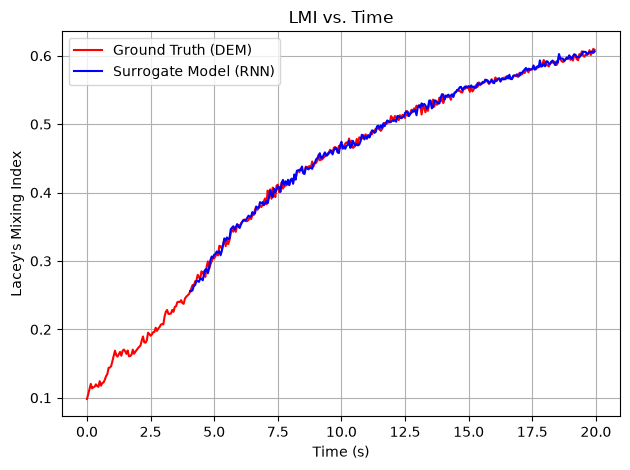

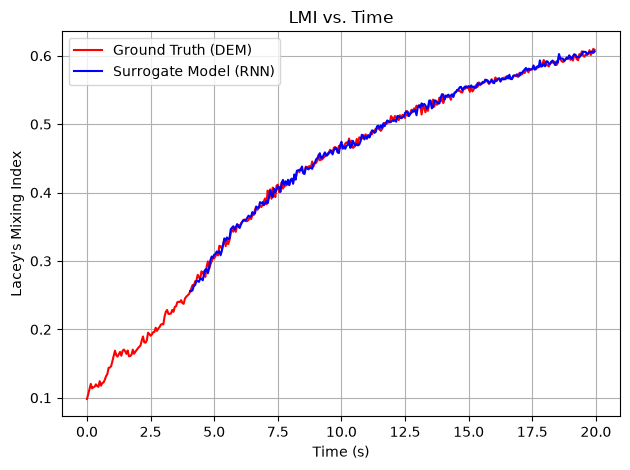

In [12]:
run_metrics.plot_lacey_comparison(metrics, config)

## 6. Result Visualization

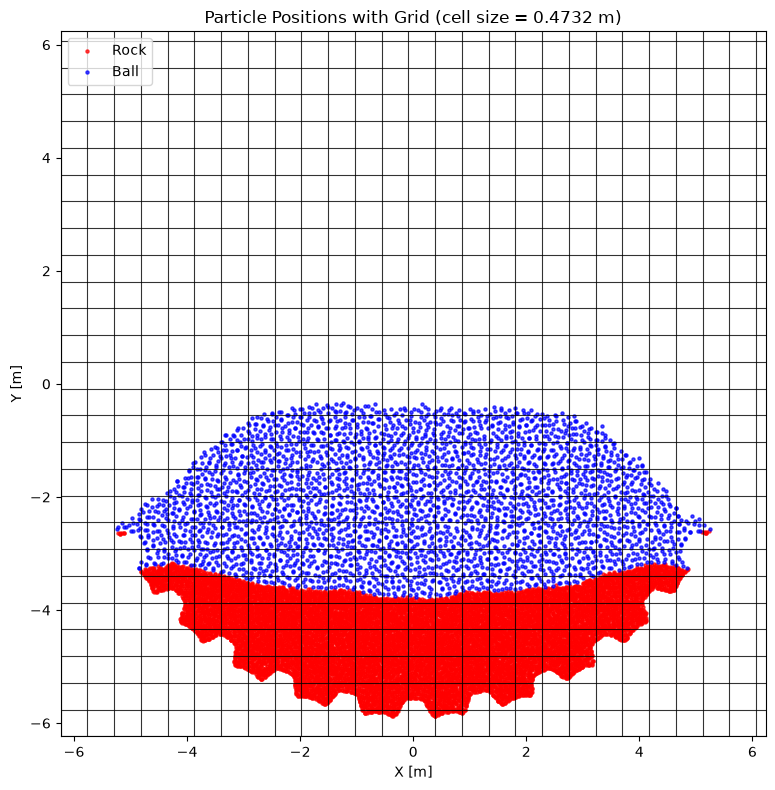

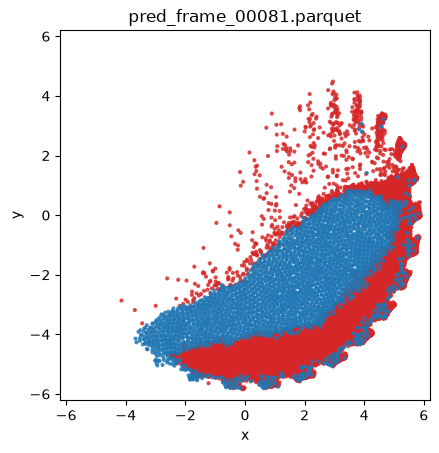

{'grid_frame': 'C:\\Users\\Fernando\\OneDrive - electro controles del noroeste\\MCD\\repo_tt\\bi-poly-particle-mix-dem-sgt-model\\data\\processed\\sic_dataset_20s_dt0p0001_parquet\\frame_00000.parquet',
 'animation': <matplotlib.animation.FuncAnimation at 0x1d9c6a9b2c0>}

In [9]:
run_visualization.generate_visualizations(config)

In [ ]:
# wea para correr todo el pipeline

"""
results = run_pipeline(config)
results.keys()

if "predictions" in results:
    display(results["predictions"].head())

if "metrics" in results:
    display(results["metrics"]["gt"].head())
    if "pred" in results["metrics"]:
        display(results["metrics"]["pred"].head())
"""